In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams["figure.figsize"] = (7,4)
plt.rcParams["font.size"] = 11



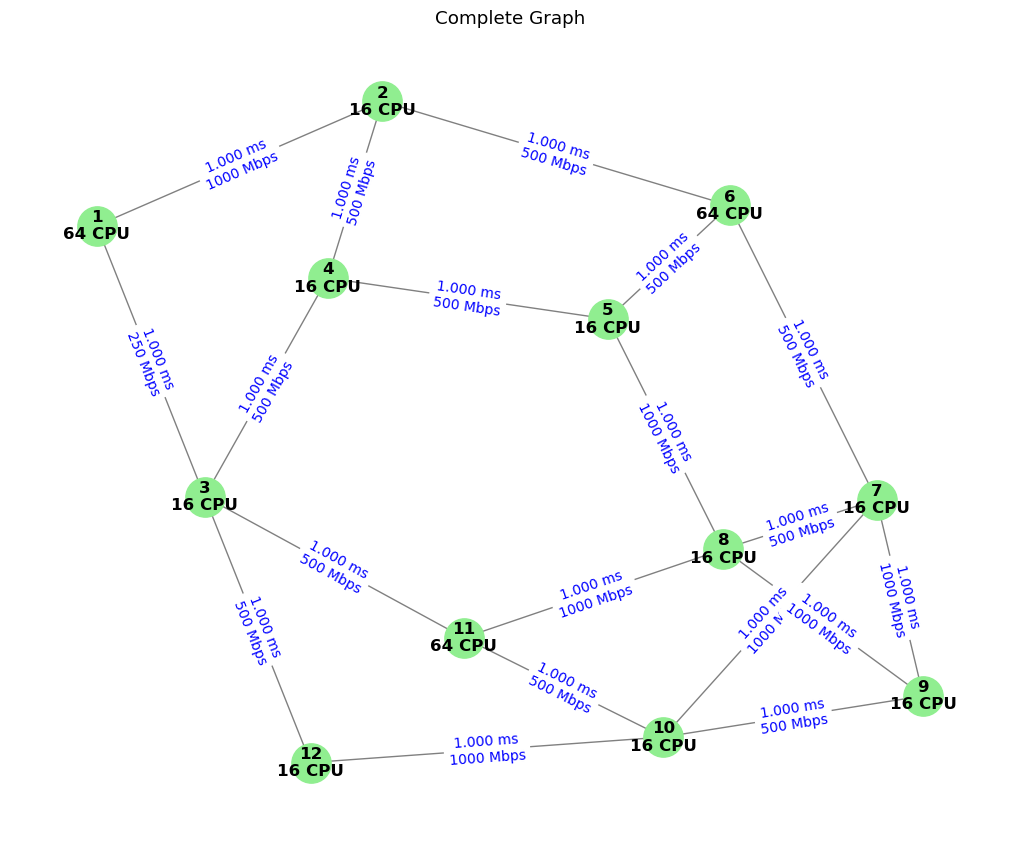

In [5]:
from utils.topology import generate_complete_graph, draw_graph, topologie_finlande

G = topologie_finlande()
draw_graph(G)

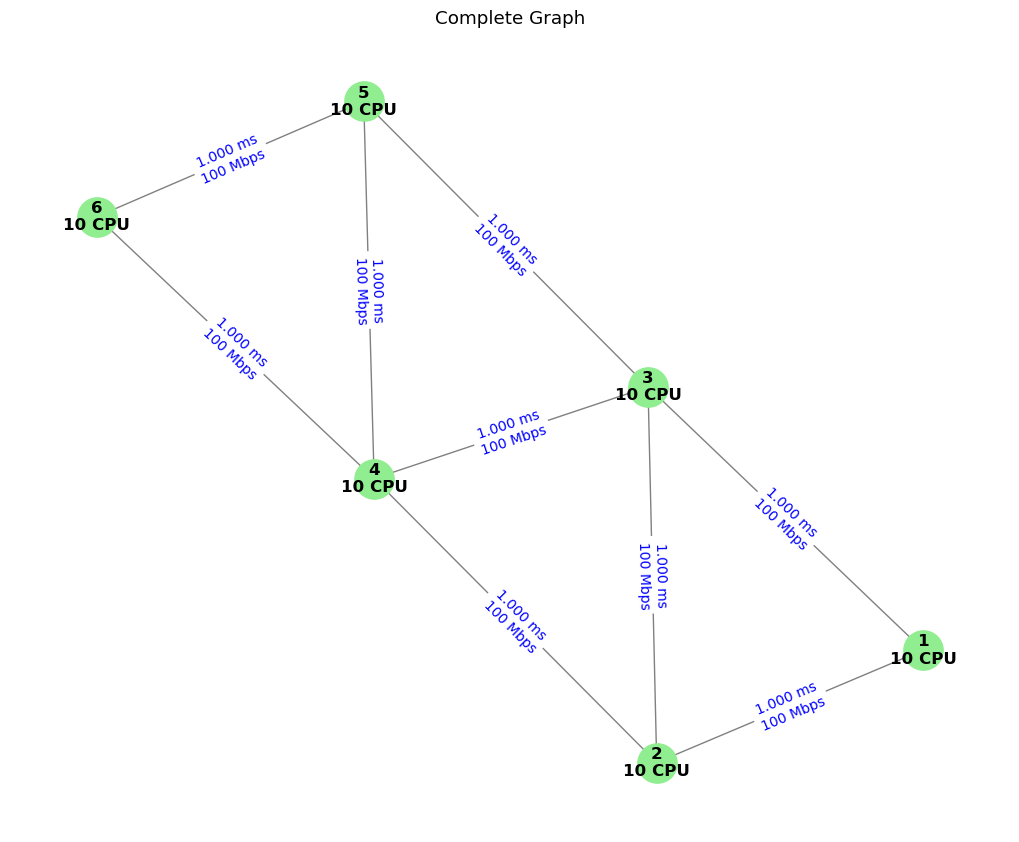

In [6]:
from utils.topology import generate_complete_graph, draw_graph, topology_bayern

G = topology_bayern()
draw_graph(G)

In [7]:
# Extract node CPU capacity directly from the topology

node_capacity_base = {
    n: G.nodes[n].get("cpu", 10)   # fallback = 10 if attribute missing
    for n in G.nodes()
}

# Extract link bandwidth directly from the topology

link_capacity_base = {
    (u, v): G.edges[u, v].get("bandwidth", 100)  # fallback = 100 Mbps
    for u, v in G.edges()
}

print("Node capacities:")
print(node_capacity_base)

print("\nLink capacities:")
print(link_capacity_base)

Node capacities:
{1: 10, 2: 10, 3: 10, 4: 10, 5: 10, 6: 10}

Link capacities:
{(1, 2): 100, (1, 3): 100, (2, 3): 100, (2, 4): 100, (3, 4): 100, (3, 5): 100, (4, 5): 100, (4, 6): 100, (5, 6): 100}


In [8]:
# Define deterministic VNF profiles for predictable slices
from utils.generate_slices import generate_random_slices
vnf_profiles = [
    {"cpu": 6, "throughput": 20, "latency": 5},
    {"cpu": 4, "throughput": 20, "latency": 5},
]

# Generate 2 slices with 2 VNFs each and entry node = 5

slices = generate_random_slices(
    G=G,
    vnf_profiles=vnf_profiles,
    num_slices=2,
    num_vnfs_per_slice=2,
    entry=5,
)

# Display generated slices

for i, (vnfs, vls, entry) in enumerate(slices):
    print(f"Slice {i} | entry = {entry}")
    print("  VNFs:")
    for v in vnfs:
        print(f"    {v['id']} | cpu={v['cpu']} | throughput={v['throughput']} | latency={v['latency']}")
    print("  VLs:")
    for vl in vls:
        print(f"    {vl['from']} -> {vl['to']} | bandwidth={vl['bandwidth']} | latency={vl['latency']}")
    print()

Slice 0 | entry = 5
  VNFs:
    vnf0_0 | cpu=6 | throughput=20 | latency=5
    vnf0_1 | cpu=4 | throughput=20 | latency=5
  VLs:
    vnf0_0 -> vnf0_1 | bandwidth=20 | latency=5

Slice 1 | entry = 5
  VNFs:
    vnf1_0 | cpu=6 | throughput=20 | latency=5
    vnf1_1 | cpu=4 | throughput=20 | latency=5
  VLs:
    vnf1_0 -> vnf1_1 | bandwidth=20 | latency=5



In [9]:
# Define node capacities (10 CPU per node)

node_capacity_base = {n: 10 for n in G.nodes()}

# Define link capacities (100 Mbps per link)

link_capacity_base = {
    (u, v): 100
    for u, v in G.edges()
}

print("Node capacities:")
print(node_capacity_base)

print("\nLink capacities:")
print(link_capacity_base)

Node capacities:
{1: 10, 2: 10, 3: 10, 4: 10, 5: 10, 6: 10}

Link capacities:
{(1, 2): 100, (1, 3): 100, (2, 3): 100, (2, 4): 100, (3, 4): 100, (3, 5): 100, (4, 5): 100, (4, 6): 100, (5, 6): 100}


In [10]:
from heuristics.best_fit import run_best_fit

# Run Best-Fit and print detailed placement/routing results

df_bf, full_results_bf = run_best_fit(
    G,
    slices,
    node_capacity_base,
    link_capacity_base,
)

print("=== Best-Fit summary ===")
display(df_bf)

print("\n=== Detailed placement and routing ===")
for i, state in enumerate(full_results_bf):
    print(f"\n--- Slice {i} ---")

    if state is None:
        print("Rejected")
        continue

    print("Accepted")

    # Placement
    print("\nVNF placement:")
    for vnf_id, node in state.placed_vnfs.items():
        print(f"  {vnf_id} -> node {node}")

    # Routing
    print("\nRoutes:")
    if not state.routed_vls:
        print("  No routed VLs")
    else:
        for vl_key, path in state.routed_vls.items():
            if vl_key[0] == "ENTRY":
                print(f"  ENTRY -> {vl_key[1]} : path {path}")
            else:
                print(f"  {vl_key[0]} -> {vl_key[1]} : path {path}")

    print(f"\nTotal accumulated latency (g_cost): {state.g_cost}")

=== Best-Fit summary ===


,slice,accepted,g_cost
0,1,True,1.0
1,2,True,2.0



=== Detailed placement and routing ===

--- Slice 0 ---
Accepted

VNF placement:
  vnf0_0 -> node 5
  vnf0_1 -> node 3

Routes:
  ENTRY -> vnf0_0 : path [5]
  vnf0_0 -> vnf0_1 : path [5, 3]

Total accumulated latency (g_cost): 1.0

--- Slice 1 ---
Accepted

VNF placement:
  vnf1_0 -> node 3
  vnf1_1 -> node 5

Routes:
  ENTRY -> vnf1_0 : path [5, 3]
  vnf1_0 -> vnf1_1 : path [3, 5]

Total accumulated latency (g_cost): 2.0
